In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
#Loading Dataset
df = pd.read_csv("../data/dataset/pakistan_air_quality_final_clean.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,timestamp,city,latitude,longitude,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,...,pressure,date,hour,day_of_week,month,month_name,year,is_weekend,season,aqi_category
0,2025-11-06 00:00:00,Faisalabad,31.4504,73.135,23.7,22.6,598.0,15.9,5.0,58.0,...,1023.4,2025-11-06,0,Thursday,11,November,2025,0,Autumn,Moderate
1,2025-11-06 01:00:00,Faisalabad,31.4504,73.135,25.4,24.2,790.0,21.7,5.6,51.0,...,1023.4,2025-11-06,1,Thursday,11,November,2025,0,Autumn,Moderate
2,2025-11-06 02:00:00,Faisalabad,31.4504,73.135,32.2,30.7,1048.0,29.4,6.5,42.0,...,1023.4,2025-11-06,2,Thursday,11,November,2025,0,Autumn,Moderate
3,2025-11-06 03:00:00,Faisalabad,31.4504,73.135,36.2,34.8,1176.0,33.2,7.2,42.0,...,1023.4,2025-11-06,3,Thursday,11,November,2025,0,Autumn,Moderate
4,2025-11-06 04:00:00,Faisalabad,31.4504,73.135,34.7,33.3,1053.0,29.3,7.6,58.0,...,1023.4,2025-11-06,4,Thursday,11,November,2025,0,Autumn,Moderate


In [3]:
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

(21840, 26)

Columns:
Index(['timestamp', 'city', 'latitude', 'longitude', 'pm10', 'pm2_5',
       'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone',
       'dust', 'temperature', 'humidity', 'precipitation', 'wind_speed',
       'wind_direction', 'pressure', 'date', 'hour', 'day_of_week', 'month',
       'month_name', 'year', 'is_weekend', 'season', 'aqi_category'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21840 entries, 0 to 21839
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         21840 non-null  object 
 1   city              21840 non-null  object 
 2   latitude          21840 non-null  float64
 3   longitude         21840 non-null  float64
 4   pm10              21840 non-null  float64
 5   pm2_5             21840 non-null  float64
 6   carbon_monoxide   21840 non-null  float64
 7   nitrogen_dioxide  21840 non-null  float6

In [4]:
df = df.dropna()

print("Missing values removed!")
print(df.shape)

Missing values removed!
(21840, 26)


In [5]:
print(df.columns)

Index(['timestamp', 'city', 'latitude', 'longitude', 'pm10', 'pm2_5',
       'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone',
       'dust', 'temperature', 'humidity', 'precipitation', 'wind_speed',
       'wind_direction', 'pressure', 'date', 'hour', 'day_of_week', 'month',
       'month_name', 'year', 'is_weekend', 'season', 'aqi_category'],
      dtype='object')


In [6]:
#SELECTING IMP FEATURES
selected_columns = [
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "temperature",
    "humidity",
    "pressure",
    "wind_speed",
    "aqi_category"
]

df = df[selected_columns]

df.head()

,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature,humidity,pressure,wind_speed,aqi_category
0,23.7,22.6,598.0,15.9,5.0,58.0,16.8,70.0,1023.4,1.0,Moderate
1,25.4,24.2,790.0,21.7,5.6,51.0,16.8,70.0,1023.4,1.0,Moderate
2,32.2,30.7,1048.0,29.4,6.5,42.0,16.8,70.0,1023.4,1.0,Moderate
3,36.2,34.8,1176.0,33.2,7.2,42.0,16.8,70.0,1023.4,1.0,Moderate
4,34.7,33.3,1053.0,29.3,7.6,58.0,16.8,70.0,1023.4,1.0,Moderate


In [7]:
#HANDLING MISSING VALUES
print(df.isnull().sum())

df = df.dropna()

print("\nAfter Cleaning:")
print(df.shape)

pm10                0
pm2_5               0
carbon_monoxide     0
nitrogen_dioxide    0
sulphur_dioxide     0
ozone               0
temperature         0
humidity            0
pressure            0
wind_speed          0
aqi_category        0
dtype: int64

After Cleaning:
(21840, 11)


In [8]:
df["aqi_category"] = df["aqi_category"].astype(str)

In [34]:
import os
import joblib
from sklearn.preprocessing import LabelEncoder

# create folder if not exists
os.makedirs("models", exist_ok=True)

le = LabelEncoder()

df["aqi_category"] = le.fit_transform(df["aqi_category"])

print("Classes mapping:")
for i, class_name in enumerate(le.classes_):
    print(i, "=", class_name)

# SAVE encoder correctly
joblib.dump(le, "models/label_encoder.pkl")

Classes mapping:
0 = 0
1 = 1
2 = 2
3 = 3
4 = 4
5 = 5


['models/label_encoder.pkl']

In [35]:
df.head(20)

,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature,humidity,pressure,wind_speed,aqi_category
0,23.7,22.6,598.0,15.9,5.0,58.0,16.8,70.0,1023.4,1.0,2
1,25.4,24.2,790.0,21.7,5.6,51.0,16.8,70.0,1023.4,1.0,2
2,32.2,30.7,1048.0,29.4,6.5,42.0,16.8,70.0,1023.4,1.0,2
3,36.2,34.8,1176.0,33.2,7.2,42.0,16.8,70.0,1023.4,1.0,2
4,34.7,33.3,1053.0,29.3,7.6,58.0,16.8,70.0,1023.4,1.0,2
5,27.9,26.2,801.0,21.5,7.9,83.0,16.8,70.0,1023.4,1.0,2
6,22.0,20.3,583.0,14.7,7.8,104.0,16.8,70.0,1023.4,1.0,2
7,17.9,15.9,435.0,8.5,7.2,119.0,16.8,70.0,1023.4,1.0,2
8,16.2,14.2,321.0,3.3,6.2,131.0,16.8,70.0,1023.4,1.0,2
9,15.2,13.2,306.0,5.8,5.8,130.0,16.8,70.0,1023.4,1.0,2


In [36]:
#FEATURE ENGINEERING
x = df.drop("aqi_category", axis=1)

Y = df["aqi_category"]

print(x.head())
print(Y.head())

   pm10  pm2_5  carbon_monoxide  nitrogen_dioxide  sulphur_dioxide  ozone  \
0  23.7   22.6            598.0              15.9              5.0   58.0   
1  25.4   24.2            790.0              21.7              5.6   51.0   
2  32.2   30.7           1048.0              29.4              6.5   42.0   
3  36.2   34.8           1176.0              33.2              7.2   42.0   
4  34.7   33.3           1053.0              29.3              7.6   58.0   

   temperature  humidity  pressure  wind_speed  
0         16.8      70.0    1023.4         1.0  
1         16.8      70.0    1023.4         1.0  
2         16.8      70.0    1023.4         1.0  
3         16.8      70.0    1023.4         1.0  
4         16.8      70.0    1023.4         1.0  
0    2
1    2
2    2
3    2
4    2
Name: aqi_category, dtype: int64


In [37]:
print(x.dtypes)
print(Y.head())

pm10                float64
pm2_5               float64
carbon_monoxide     float64
nitrogen_dioxide    float64
sulphur_dioxide     float64
ozone               float64
temperature         float64
humidity            float64
pressure            float64
wind_speed          float64
dtype: object
0    2
1    2
2    2
3    2
4    2
Name: aqi_category, dtype: int64


In [38]:
#Spliting Data into train and test data
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    x,
    Y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (17472, 10)
Test: (4368, 10)


In [39]:
#TRAIN MODEL (RANDOM FOREST)
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, Y_train)

print("Model trained successfully!")

Model trained successfully!


In [40]:
#Predictions
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 3 2 3 3 5 2 4 3 3]


In [41]:
#EVALUATION
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(Y_test, y_pred))

print("\nClassification Report:")
print(classification_report(Y_test, y_pred))

Accuracy: 0.9997710622710623

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       155
           1       1.00      1.00      1.00       133
           2       1.00      1.00      1.00       972
           3       1.00      1.00      1.00      1731
           4       1.00      1.00      1.00       877
           5       1.00      1.00      1.00       500

    accuracy                           1.00      4368
   macro avg       1.00      1.00      1.00      4368
weighted avg       1.00      1.00      1.00      4368



In [42]:
'''Model is overfitted lets resolve this issue'''

'Model is overfitted lets resolve this issue'

In [43]:
df.corr(numeric_only=True)

,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature,humidity,pressure,wind_speed,aqi_category
pm10,1.000000,0.971485,0.614257,0.486627,0.558332,-0.360274,0.045710,0.315249,-0.181143,-0.273420,0.335158
pm2_5,0.971485,1.000000,0.652475,0.516805,0.593744,-0.368484,0.074648,0.332204,-0.170919,-0.331996,0.350421
carbon_monoxide,0.614257,0.652475,1.000000,0.677970,0.560742,-0.405714,0.092924,0.142383,-0.137201,-0.265049,0.285459
nitrogen_dioxide,0.486627,0.516805,0.677970,1.000000,0.512621,-0.657077,0.225084,-0.099552,-0.062255,-0.148299,0.239871
sulphur_dioxide,0.558332,0.593744,0.560742,0.512621,1.000000,0.030121,0.312643,0.138627,-0.197558,-0.146261,0.253704
ozone,-0.360274,-0.368484,-0.405714,-0.657077,0.030121,1.000000,-0.071155,0.091103,0.135600,0.042695,-0.181333
temperature,0.045710,0.074648,0.092924,0.225084,0.312643,-0.071155,1.000000,-0.472327,-0.231990,0.272221,0.139834
humidity,0.315249,0.332204,0.142383,-0.099552,0.138627,0.091103,-0.472327,1.000000,-0.113072,-0.383095,0.240828
pressure,-0.181143,-0.170919,-0.137201,-0.062255,-0.197558,0.135600,-0.231990,-0.113072,1.000000,-0.153682,-0.135592
wind_speed,-0.273420,-0.331996,-0.265049,-0.148299,-0.146261,0.042695,0.272221,-0.383095,-0.153682,1.000000,-0.118582


In [44]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [45]:
''' Data is too cleaned for real world ml and random forest is very strong  so now we add some noise to eliminate overfitting'''


' Data is too cleaned for real world ml and random forest is very strong  so now we add some noise to eliminate overfitting'

In [46]:
#Add noise
import numpy as np

X_noisy = x.copy()

noise_factor = 0.02

X_noisy = X_noisy + np.random.normal(0, noise_factor, X_noisy.shape)

In [47]:
#USING CROSS VALIDATION
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, x, Y, cv=5)

print("CV Scores:", scores)
print("Mean:", scores.mean())

CV Scores: [1.         1.         1.         0.99954212 1.        ]
Mean: 0.9999084249084248


In [48]:
model.predict(X_test)

array([0, 3, 2, ..., 2, 1, 4], shape=(4368,))

In [49]:
model.predict_proba(X_test)

array([[0.96, 0.  , 0.04, 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 1.  , 0.  , 0.  ],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  ],
       ...,
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.02, 0.02, 0.96, 0.  ]], shape=(4368, 6))

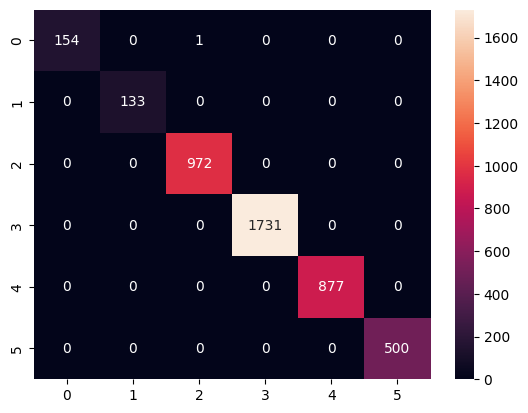

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.show()

In [51]:
#Saving Model
joblib.dump(model, "../models/aqi_model.pkl")
joblib.dump(le, "../models/label_encoder.pkl")

print("Model training completed and saved!")

Model training completed and saved!


In [52]:
df["aqi_category"].unique()

array([2, 4, 3, 5, 1, 0])

In [53]:
import os

os.makedirs("models", exist_ok=True)

import joblib
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["aqi_category"] = le.fit_transform(df["aqi_category"])

joblib.dump(le, "models/label_encoder.pkl")

print("Saved classes:", le.classes_)

Saved classes: [0 1 2 3 4 5]


In [54]:
#SAVE MODEL
joblib.dump(model, "models/aqi_model.pkl")

['models/aqi_model.pkl']

In [55]:
print(le.classes_)

[0 1 2 3 4 5]
